# Medical Image Triage with vision-language models and vLLM

This notebook provides a step-by-step guide to building a medical image triage system
using a vision-language model with vLLM and Gradio for inference.
 
The goal is not to make a definitive diagnosis. Instead, the model should classify the image
into a conservative triage category, identify whether it looks like an X-ray, a normal photo, or a prescription,
and extract prescription text when present.
 
This tutorial explores how to use a vision model for first-pass triage and then hand the structured output
to a Qwen-based conversational layer in the companion notebook. It covers the following topics:

[Installing dependencies](#install-deps)  
[Building medical image triage with vLLM](#cli-ocr)  
[Transforming triage into a GUI-enabled system with multiple model choices](#gradio-gui)


The tutorial uses vLLM for large language model (LLM) inference. vLLM optimizes text generation workloads by effectively batching requests and utilizing GPU resources, offering high throughput and low latency.

![Medical Triage Example](./assets/ocr.gif)
---

## Prerequisites

### Hugging Face API access

* Obtain an API token from [Hugging Face](https://huggingface.co) for downloading models.
* Ensure the Hugging Face API token has the necessary permissions and approval to access the [Meta Llama checkpoints](https://huggingface.co/meta-llama/Llama-3.1-8B).

<a id="install-deps"></a>
## 1. Installing dependencies

Install the libraries needed for this tutorial. Run the following commands inside the Jupyter notebook running within the Docker container:

In [1]:
!pip install gradio requests

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.7/19.7 MB 72.7 MB/s  0:00:00eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 134.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10/10 [gradio] 9/10 [gradio]

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


### Provide your Hugging Face token

You'll require a Hugging Face API token to access Llama-3.1-8B. Generate your token at [Hugging Face Tokens](https://huggingface.co/settings/tokens) and request access for [Llama-3.2-11B-Vision-Instruct](https://huggingface.co/meta-llama/Llama-3.2-11B-Vision-Instruct). Tokens typically start with "hf_".

Run the following interactive block in your Jupyter notebook to set up the token:

In [2]:
from huggingface_hub import notebook_login, HfApi

# Prompt the user to log in
notebook_login()


Verify that your token was accepted correctly:

In [3]:
# Validate the token
try:
    api = HfApi()
    user_info = api.whoami()
    print(f"Token validated successfully! Logged in as: {user_info['name']}")
except Exception as e:
    print(f"Token validation failed. Error: {e}")


Token validated successfully! Logged in as: Rurouni-II


<a id="cli-ocr"></a>
## 2. Building medical image triage with vLLM

First, define the `ImageInference` inference class. This class provides a constructor to initialize a model for inference. Additionally, it defines another function that runs triage inference on an image that you provide. 

In [10]:
from vllm import LLM, SamplingParams
from transformers import AutoTokenizer
from PIL import Image

current_model = "Qwen/Qwen2-VL-7B-Instruct"

class ImageInference:
    def __init__(self, model_name=current_model):
        print(f"--- Initializing ImageInference with {model_name} ---")
        self.model_name = model_name

        print("Loading LLM (this may take a minute)...")
        self.llm = LLM(
            model=model_name, 
            max_model_len=4096, 
            max_num_seqs=16, 
            enforce_eager=True,
            trust_remote_code=True,
            gpu_memory_utilization=0.4
        )

        print("Loading Tokenizer...")
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        print("--- Initialization Complete! ---")

    def generate_image_output(self, image: Image, patient_context: str = "") -> str:
        if not hasattr(self, 'tokenizer'):
            return "Error: Tokenizer was never loaded during initialization!"

        context_block = f"Patient context: {patient_context}\n" if patient_context else ""
        # Use a list for 'content' to support multimodal models like Qwen2-VL
        messages = [{
            'role': 'user',
            'content': [
                {"type": "image"},
                {"type": "text", "text": (
                    "You are a medical image triage assistant. Analyze the provided image and return a concise structured assessment.\n"
                    "Classify the image as one of: xray, normal_photo, prescription, or unknown.\n"
                    "If the image looks like a prescription, extract the visible text exactly.\n"
                    "If the image looks like a medical photo or X-ray, give a conservative triage label such as normal, monitor, urgent, or emergency.\n"
                    "Use the following format exactly:\n"
                    "image_type: <one of xray|normal_photo|prescription|unknown>\n"
                    "triage_label: <normal|monitor|urgent|emergency|not_applicable>\n"
                    "summary: <one short sentence>\n"
                    "findings: <bullet-style semicolon-separated details>\n"
                    "prescription_text: <exact text or none>\n"
                    "follow_up_questions: <up to 3 questions for the doctor-style Q&A layer>\n"
                    f"{context_block}"
                    "Do not provide a final diagnosis. Do not add commentary outside the requested format."
                )}
            ]
        }]
        
        # apply_chat_template will now correctly insert <|vision_start|><|vision_end|> for Qwen
        prompt = self.tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

        sampling_params = SamplingParams(max_tokens=512, temperature=0.2)

        outputs = self.llm.generate({
            "prompt": prompt,
            "multi_modal_data": {"image": image},
        }, sampling_params=sampling_params)

        generated_text = outputs[0].outputs[0].text if outputs else "No output generated."
        return generated_text

### Testing the triage system

Download [this test image](https://github.com/ROCm/gpuaidev/tree/main/docs/notebooks/assets/together_we_advance_.png) by running the following command:

Now it's time to test your triage system. First read the image, then view it.

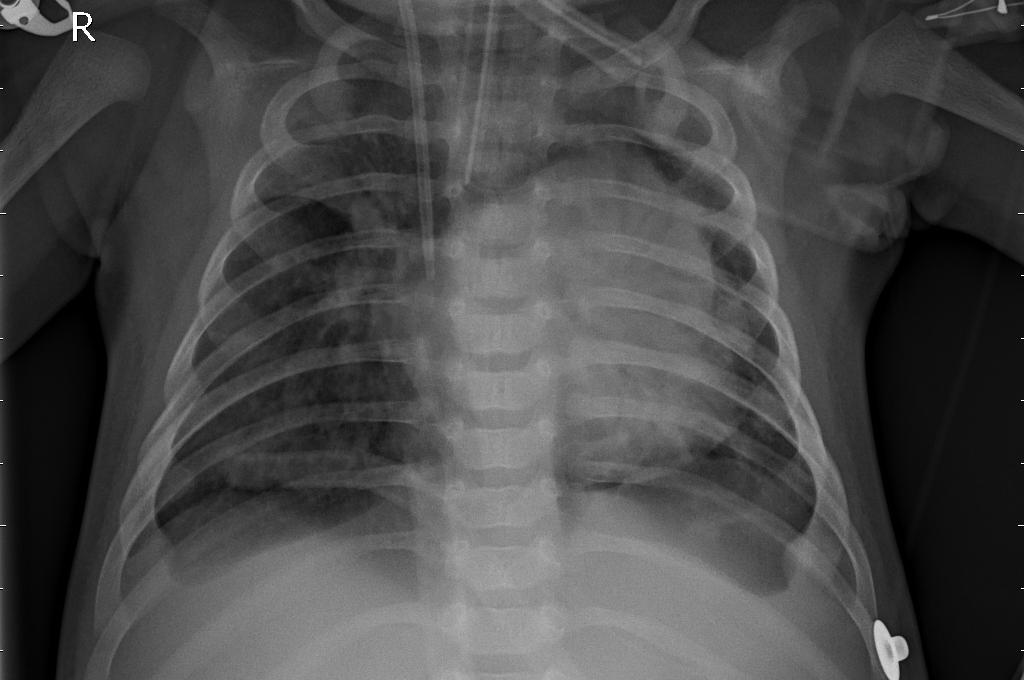

In [11]:
pil_image = Image.open("/shared-docker/person100_bacteria_477.jpeg")
pil_image = pil_image.convert("RGB")  # Ensure the image is in RGB format
pil_image

Next, initialize an instance of the `ImageInference` class.

In [12]:
# Initialize the inference class
inference = ImageInference()

--- Initializing ImageInference with Qwen/Qwen2-VL-7B-Instruct ---
Loading LLM (this may take a minute)...
INFO 05-09 19:34:05 [utils.py:238] non-default args: {'trust_remote_code': True, 'max_model_len': 4096, 'gpu_memory_utilization': 0.4, 'max_num_seqs': 16, 'disable_log_stats': True, 'enforce_eager': True, 'model': 'Qwen/Qwen2-VL-7B-Instruct'}


The argument `trust_remote_code` is to be used with Auto classes. It has no effect here and is ignored.


config.json: 0.00B [00:00, ?B/s]

The argument `trust_remote_code` is to be used with Auto classes. It has no effect here and is ignored.


preprocessor_config.json:   0%|          | 0.00/347 [00:00<?, ?B/s]

...

WARNING 05-09 19:34:18 [system_utils.py:152] We must use the `spawn` multiprocessing start method. Overriding VLLM_WORKER_MULTIPROC_METHOD to 'spawn'. See https://docs.vllm.ai/en/latest/usage/troubleshooting.html#python-multiprocessing for more information. Reasons: CUDA is initialized
(EngineCore_DP0 pid=259) INFO 05-09 19:34:24 [core.py:101] Initializing a V1 LLM engine (v0.17.1) with config: model='Qwen/Qwen2-VL-7B-Instruct', speculative_config=None, tokenizer='Qwen/Qwen2-VL-7B-Instruct', skip_tokenizer_init=False, tokenizer_mode=auto, revision=None, tokenizer_revision=None, trust_remote_code=True, dtype=torch.bfloat16, max_seq_len=4096, download_dir=None, load_format=auto, tensor_parallel_size=1, pipeline_parallel_size=1, data_parallel_size=1, disable_custom_all_reduce=False, quantization=None, enforce_eager=True, enable_return_routed_experts=False, kv_cache_dtype=auto, device_config=cuda, structured_outputs_config=StructuredOutputsConfig(backend='auto', disable_fallback=False, dis

(EngineCore_DP0 pid=259) The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. Note that this behavior will be extended to all models in a future release.


(EngineCore_DP0 pid=259) INFO 05-09 19:34:29 [base.py:106] Offloader set to NoopOffloader
(EngineCore_DP0 pid=259) INFO 05-09 19:34:29 [gpu_model_runner.py:4281] Starting to load model Qwen/Qwen2-VL-7B-Instruct...
(EngineCore_DP0 pid=259) INFO 05-09 19:34:30 [rocm.py:508] Using Flash Attention backend for ViT model.
(EngineCore_DP0 pid=259) INFO 05-09 19:34:30 [mm_encoder_attention.py:215] Using AttentionBackendEnum.FLASH_ATTN for MMEncoderAttention.
(EngineCore_DP0 pid=259) INFO 05-09 19:34:30 [vllm.py:747] Asynchronous scheduling is enabled.
(EngineCore_DP0 pid=259) WARNING 05-09 19:34:30 [vllm.py:781] Enforce eager set, disabling torch.compile and CUDAGraphs. This is equivalent to setting -cc.mode=none -cc.cudagraph_mode=none
(EngineCore_DP0 pid=259) WARNING 05-09 19:34:30 [vllm.py:792] Inductor compilation was disabled by user settings, optimizations settings that are only active during inductor compilation will be ignored.
(EngineCore_DP0 pid=259) INFO 05-09 19:34:30 [vllm.py:957]

Loading safetensors checkpoint shards:   0% Completed | 0/5 [00:00<?, ?it/s]
Loading safetensors checkpoint shards:  20% Completed | 1/5 [00:01<00:05,  1.38s/it]
Loading safetensors checkpoint shards:  40% Completed | 2/5 [00:02<00:04,  1.42s/it]
Loading safetensors checkpoint shards:  60% Completed | 3/5 [00:04<00:02,  1.41s/it]
Loading safetensors checkpoint shards:  80% Completed | 4/5 [00:05<00:01,  1.40s/it]
Loading safetensors checkpoint shards: 100% Completed | 5/5 [00:06<00:00,  1.06s/it]
Loading safetensors checkpoint shards: 100% Completed | 5/5 [00:06<00:00,  1.21s/it]
(EngineCore_DP0 pid=259) 


(EngineCore_DP0 pid=259) INFO 05-09 19:34:45 [default_loader.py:293] Loading weights took 6.09 seconds
(EngineCore_DP0 pid=259) INFO 05-09 19:34:45 [gpu_model_runner.py:4364] Model loading took 15.74 GiB memory and 15.633723 seconds
(EngineCore_DP0 pid=259) INFO 05-09 19:34:45 [gpu_model_runner.py:5280] Encoder cache will be initialized with a budget of 16384 tokens, and profiled with 1 video items of the maximum feature size.
(EngineCore_DP0 pid=259) INFO 05-09 19:34:57 [gpu_worker.py:424] Available KV cache memory: 57.96 GiB
(EngineCore_DP0 pid=259) INFO 05-09 19:34:57 [kv_cache_utils.py:1314] GPU KV cache size: 1,085,344 tokens
(EngineCore_DP0 pid=259) INFO 05-09 19:34:57 [kv_cache_utils.py:1319] Maximum concurrency for 4,096 tokens per request: 264.98x
(EngineCore_DP0 pid=259) INFO 05-09 19:34:57 [core.py:282] init engine (profile, create kv cache, warmup model) took 12.10 seconds
(EngineCore_DP0 pid=259) WARNING 05-09 19:34:58 [vllm.py:781] Enforce eager set, disabling torch.compi

In [7]:
print(f"Object type: {type(inference)}")
print(f"Attributes: {dir(inference)}")

Object type: <class '__main__.ImageInference'>
Attributes: ['__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', 'generate_image_output', 'init']


Now pass the image to the model for inference and print the results.

In [13]:
import inspect
print(inspect.getsource(ImageInference))

OSError: source code not available

In [14]:

# Generate output for the image
output = inference.generate_image_output(pil_image)

# Print the result
print("Model Output:")
print(output)

Rendering prompts:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0% 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Model Output:
image_type: xray
triage_label: normal
summary: Chest X-ray of a patient with no apparent abnormalities.
findings: No visible fractures, no signs of pneumothorax, clear lung fields, normal heart size, no masses or foreign bodies.
prescription_text: None
follow_up_questions: 1. Is there a history of respiratory issues or allergies? 2. Are there any symptoms the patient is experiencing? 3. Should the patient be referred to a specialist?


Congratulations. You've just built a medical image triage system. That gives you a first-pass classifier and a structured handoff for a doctor-style Q&A flow.

<a id="gradio-gui"></a>
## 3. Transforming triage into a GUI-enabled system with multiple model choices

To provide a graphical interface for your assistant, use [Gradio](https://www.gradio.app/) to create an interactive web-based UI.

### Import Gradio and define a shortlist of vision models to access

You're going to create a shortlist of models that can analyze medical images. The full list is available [here](https://docs.vllm.ai/en/latest/models/supported_models.html).

In [23]:
import gradio as gr

# Define available models and their Hugging Face model IDs
MODEL_OPTIONS = {
    "Llama-3.2-11B-Vision-Instruct": "meta-llama/Llama-3.2-11B-Vision-Instruct",
    "Qwen2-VL (2B)": "Qwen/Qwen2-VL-2B-Instruct",
    "Qwen2-VL (7B)": "Qwen/Qwen2-VL-7B-Instruct",
    "Phi-3.5 Vision": "microsoft/Phi-3.5-vision-instruct",
}

In [16]:
!pip install chromadb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 117.6 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 213.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 184.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13/13 [chromadb]/13 [chromadb]s]]

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [18]:
!pip install sentence_transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.3/571.3 kB 17.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 83.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [sentence_transformers]ence_transformers]

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [19]:
import hashlib
import json
import os
from typing import Any

import chromadb
from chromadb.utils.embedding_functions import SentenceTransformerEmbeddingFunction

VECTOR_DB_PATH = os.path.join(os.getcwd(), "medical_memory_chroma")
EMBEDDING_MODEL = "all-MiniLM-L6-v2"

embedding_function = SentenceTransformerEmbeddingFunction(model_name=EMBEDDING_MODEL)
chroma_client = chromadb.PersistentClient(path=VECTOR_DB_PATH)
medical_collection = chroma_client.get_or_create_collection(
    name="medical_triage_notes",
    embedding_function=embedding_function,
)


def triage_text_to_dict(text: str) -> dict[str, Any]:
    out = {}
    for line in text.splitlines():
        line = line.strip()
        if not line or ':' not in line:
            continue
        k, v = line.split(':', 1)
        out[k.strip()] = v.strip()
    if 'follow_up_questions' in out:
        out['follow_up_questions'] = [q.strip() for q in out['follow_up_questions'].split(',') if q.strip()]
    return out


def save_triage_json(triage_report: dict[str, Any], path: str = "triage_report.json") -> str:
    os.makedirs(os.path.dirname(path) or '.', exist_ok=True)
    with open(path, 'w', encoding='utf-8') as f:
        json.dump(triage_report, f, ensure_ascii=False, indent=2)
    return path


def upsert_triage_to_chroma(triage_report: dict[str, Any], conversation_id: str = "default") -> str:
    document = "\n".join(
        [
            f"image_type: {triage_report.get('image_type', '')}",
            f"triage_label: {triage_report.get('triage_label', '')}",
            f"summary: {triage_report.get('summary', '')}",
            f"findings: {triage_report.get('findings', '')}",
            f"prescription_text: {triage_report.get('prescription_text', 'none')}",
            f"follow_up_questions: {', '.join(triage_report.get('follow_up_questions', []))}",
        ]
    )
    record_id = hashlib.sha1(f"{conversation_id}:{document}".encode('utf-8')).hexdigest()
    medical_collection.upsert(
        ids=[record_id],
        documents=[document],
        metadatas=[{"conversation_id": conversation_id, "kind": "triage_report"}],
    )
    return record_id


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

[2026-05-09 19:37:03] INFO model.py:973: Loading SentenceTransformer model from sentence-transformers/all-MiniLM-L6-v2.


README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
!pip install -q chromadb sentence-transformers


### Create the Gradio interface

Next, define two simple helper functions for switching models and running inference using your previously defined class, followed by Gradio blocks:

In [20]:
def switch_model(model_name):
    global inference, current_model
    try:
        inference = ImageInference(model_name=model_name)
        current_model = model_name
        return f"Switched to model: {model_name}", f"Current Model: {current_model}"
    except Exception as e:
        return f"Failed to switch model: {str(e)}", f"Current Model: {current_model}"


def analyze_image(image, patient_context):
    try:
        if image is None:
            return "Please upload an image first."
        pil_image = image.convert("RGB")
        result_text = inference.generate_image_output(pil_image, patient_context=patient_context or "")
        # Parse generated triage text into a dict
        triage_report = triage_text_to_dict(result_text)
        # Save JSON handoff
        try:
            json_path = save_triage_json(triage_report)
        except Exception:
            json_path = None
        # Upsert into Chroma vector DB
        try:
            record_id = upsert_triage_to_chroma(triage_report)
        except Exception:
            record_id = None
        output_lines = ["### Model Output", "", "```", result_text, "```", ""]
        if json_path:
            output_lines += [f"Saved triage JSON: {json_path}"]
        if record_id:
            output_lines += [f"Stored triage record id: {record_id}"]
        return "\n".join(output_lines)
    except Exception as e:
        return f"Error processing the image: {str(e)}"


Execute the code block below to launch the GUI. The interface displays in your browser, letting you interact with the triage system.

In [24]:
import gradio as gr

# Create the Gradio interface
with gr.Blocks(theme=gr.themes.Soft()) as interface:
    gr.Markdown("# 🏥 Medical Image Triage System")
    gr.Markdown("Upload a medical image (X-ray, photo, or prescription) to receive a structured triage report.")
    
    with gr.Row():
        model_dropdown = gr.Dropdown(
            choices=list(MODEL_OPTIONS.keys()), 
            value=list(MODEL_OPTIONS.keys())[0], 
            label="Select Vision Model"
        )
        status_text = gr.Textbox(label="System Status", value=f"Current Model: {current_model}", interactive=False)
        
    # Connect model switching
    model_dropdown.change(switch_model, inputs=model_dropdown, outputs=[status_text, status_text])
    
    with gr.Row():
        with gr.Column(scale=1):
            image_input = gr.Image(type="pil", label="Upload Image")
            context_input = gr.Textbox(label="Patient Context (Optional)", placeholder="e.g. Symptoms, age, duration...")
            analyze_btn = gr.Button("🔍 Run Triage Analysis", variant="primary")
        
        with gr.Column(scale=1):
            output_markdown = gr.Markdown("### Results will appear here...")
            
    # Connect analysis function
    analyze_btn.click(
        analyze_image, 
        inputs=[image_input, context_input], 
        outputs=output_markdown
    )

print("Gradio interface 'interface' has been defined successfully.")


Gradio interface 'interface' has been defined successfully.


/tmp/ipykernel_67/516243396.py:4: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  with gr.Blocks(theme=gr.themes.Soft()) as interface:


In [25]:
interface.launch(share=True)

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://fa42607ae898ecd04c.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Rendering prompts:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0% 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

--- Initializing ImageInference with Phi-3.5 Vision ---
Loading LLM (this may take a minute)...
INFO 05-09 19:40:24 [utils.py:238] non-default args: {'trust_remote_code': True, 'max_model_len': 4096, 'gpu_memory_utilization': 0.4, 'max_num_seqs': 16, 'disable_log_stats': True, 'enforce_eager': True, 'model': 'Phi-3.5 Vision'}


...

Processed prompts:   0% 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Rendering prompts:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0% 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

## Conclusion

In this tutorial, you accomplished the following tasks:

* Built a medical image triage class using vLLM.
* Extended the functionality by adding a GUI and a selection of multiple different models.
* Produced a structured handoff that can feed the Qwen follow-up notebook.

Happy coding! If you encounter issues or have questions, don’t hesitate to ask or raise an issue on our [Github page](https://github.com/ROCm/gpuaidev)!